# Data Exploratory Analysis of Flight Cancellations & Delays 

#### Author Name: Tejas Panhale 
#### Project Type: Data Analysis (EDA)  
#### Dataset: flights_sample_3m.csv

## Objective
Purpose The purpose of this project is to investigate the patterns of flight delays and cancellations to find operational inefficiencies, identify seasonal trends, and discover the primary reasons for delays.

This analysis aims to derive business insights that could help airlines improve punctuality and operational planning.

In [2]:
# Libraries required for the project are imported in this cell 

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
## Loading of the dataset saved locally

df = pd.read_csv("../data/raw/flights_sample_3m.csv")

# Display first few rows
df.head()


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display last few rows

df.tail()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
2999995,2022-11-13,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1522,JAX,"Jacksonville, FL",CLT,"Charlotte, NC",...,0.0,85.0,71.0,55.0,328.0,NaN,NaN,NaN,NaN,NaN
2999996,2022-11-02,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1535,ORD,"Chicago, IL",AUS,"Austin, TX",...,0.0,176.0,145.0,130.0,977.0,NaN,NaN,NaN,NaN,NaN
2999997,2022-09-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2745,HSV,"Huntsville, AL",ATL,"Atlanta, GA",...,0.0,55.0,50.0,28.0,151.0,0.0,36.0,0.0,0.0,0.0
2999998,2019-11-13,Republic Airline,Republic Airline: YX,YX,20452,6134,BOS,"Boston, MA",LGA,"New York, NY",...,0.0,88.0,77.0,50.0,184.0,NaN,NaN,NaN,NaN,NaN
2999999,2019-06-15,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2823,LGB,"Long Beach, CA",SJC,"San Jose, CA",...,0.0,70.0,63.0,52.0,324.0,NaN,NaN,NaN,NaN,NaN


## Dataset Overview

We will now examine:
- The number of rows and columns
- Data types
- Missing values
- Basic data summary


In [5]:
df.shape

(3000000, 32)

##### As per above output this dataset contains 3000000 rows and 32 columns. 

In [6]:
df.info() # To get the dataset column names and its datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

#### To understand the completeness of our dataset, we calculate the total number of missing values in each column and sort them in descending order.

In [7]:
df.isnull().sum().sort_values(ascending=False) 

CANCELLATION_CODE          2920860
DELAY_DUE_LATE_AIRCRAFT    2466137
DELAY_DUE_CARRIER          2466137
DELAY_DUE_SECURITY         2466137
DELAY_DUE_NAS              2466137
DELAY_DUE_WEATHER          2466137
ARR_DELAY                    86198
ELAPSED_TIME                 86198
AIR_TIME                     86198
WHEELS_ON                    79944
TAXI_IN                      79944
ARR_TIME                     79942
WHEELS_OFF                   78806
TAXI_OUT                     78806
DEP_DELAY                    77644
DEP_TIME                     77615
CRS_ELAPSED_TIME                14
DEST_CITY                        0
CRS_DEP_TIME                     0
DEST                             0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
AIRLINE                          0
AIRLINE_DOT                      0
FL_DATE                          0
AIRLINE_CODE                     0
DIVERTED            

## Data Cleaning

Delay-related columns contain missing values because they are only populated when a delay occurs.

NOw we will replace NaN values in delay columns with 0 to correctly represent "no delay".


In [8]:
delay_columns = ['DELAY_DUE_LATE_AIRCRAFT',
                 'DELAY_DUE_CARRIER',
                 'DELAY_DUE_SECURITY',
                 'DELAY_DUE_NAS',
                 'DELAY_DUE_WEATHER']
    
df[delay_columns] = df[delay_columns].fillna(0)

df[delay_columns].isnull().sum()

DELAY_DUE_LATE_AIRCRAFT    0
DELAY_DUE_CARRIER          0
DELAY_DUE_SECURITY         0
DELAY_DUE_NAS              0
DELAY_DUE_WEATHER          0
dtype: int64

## Cancellation Analysis

Now we will calculate the total number and percentage of cancelled flights.


In [9]:
total_flights = len(df)

cancelled_flights = df['CANCELLED'].sum()

cancellation_rate = (cancelled_flights / total_flights) * 100

print(f"""
Flight Cancellation Summary
------------------------------
Total Flights      : {total_flights:,}
Cancelled Flights  : {cancelled_flights:,}
Cancellation Rate  : {cancellation_rate:.2f}%
""")



Flight Cancellation Summary
------------------------------
Total Flights      : 3,000,000
Cancelled Flights  : 79,140.0
Cancellation Rate  : 2.64%



### Insight

The overall cancellation rate is 2.64%, meaning that approximately 97% of flights operate successfully.

This suggests that cancellations are relatively uncommon compared to delays, and operational inefficiency will show as a delay rather than as a cancellation.


## Arrival Delay Analysis

We analyze arrival delay statistics to understand:

- Average delay
- Maximum delay
- Early arrivals (negative delay values)
- Overall distribution of delay times

In [13]:
pd.set_option('display.float_format', '{:.2f}'.format) # To Show all float numbers in pandas with exactly 2 decimal places

df['ARR_DELAY'].describe()


count   2913802.00
mean          4.26
std          51.17
min         -96.00
25%         -16.00
50%          -7.00
75%           7.00
max        2934.00
Name: ARR_DELAY, dtype: float64

###  Insight

The average arrival delay is approximately 4.26 minutes, while the median delay is -7 minutes, it means that more than half of the flights are arrived 
early.

The maximum delay (2934 minutes) and high standard deviation (51.17 minutes) suggest the presence of extreme outliers that skew the distribution.

Overall, most flights operate close to schedule with only a small proportion experiencing severe delays.


## Creating Delay Classification

A flight is considered delayed if the arrival delay exceeds 15 minutes.
We create a new binary column to classify delayed vs non-delayed flights.


In [16]:
# Create delay flag (1 if ARR_DELAY > 15, else 0)
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

# Count delayed vs non-delayed flights
df['IS_DELAYED'].value_counts()

# Calculate delay percentage
delay_rate = df['IS_DELAYED'].mean() * 100

print(f"Delay Rate (>15 mins): {delay_rate:.2f}%")


Delay Rate (>15 mins): 17.18%


### Insight

Approximately 17.18% of flights experience significant arrival delays (greater than 15 minutes), while only 2.64% of flights are cancelled.

This indicates that delays are a far more frequent operational issue compared to cancellations. 

Improving delay management could have a greater impact on overall service reliability than focusing solely on cancellations.


## Distribution of Arrival Delays

We visualize the distribution of arrival delays to understand the spread and presence of extreme values.


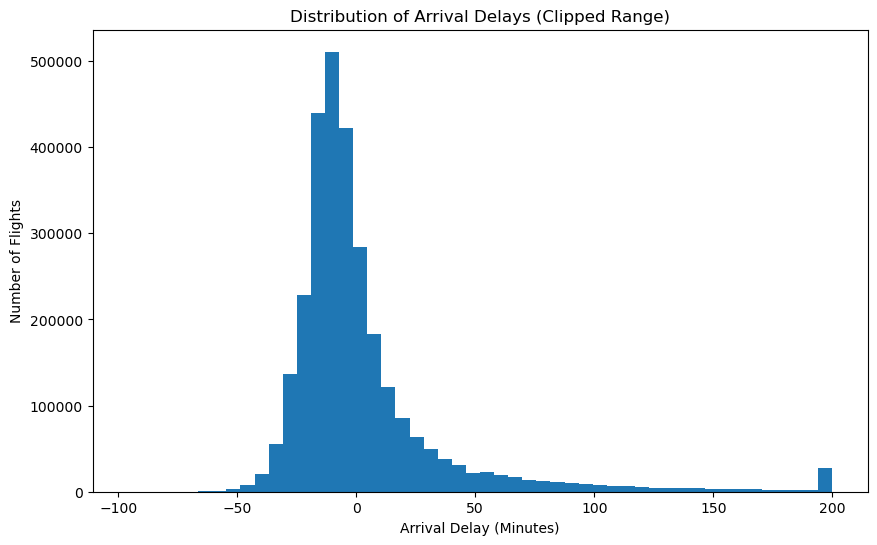

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['ARR_DELAY'].clip(-100, 200), bins=50)
plt.title("Distribution of Arrival Delays (Clipped Range)")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")
plt.show()


## Insight

The distribution of arrival delays is heavily concentrated around zero, indicating that most flights arrive close to schedule.

The distribution is right-skewed, with a long tail extending toward higher delay values. 
This confirms the presence of extreme delay outliers, which significantly increase the mean delay value.

Overall, the majority of flights operate within a reasonable time window, with only a small proportion experiencing severe delays.


## Airline-wise Average Delay

We will now analyze average arrival delay by airline to identify performance differences.


In [29]:
airline_delay = df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False)

airline_delay_formatted = airline_delay.round(2).astype(str) + " minutes"

airline_delay_formatted

AIRLINE
Allegiant Air                         13.28 minutes
JetBlue Airways                       12.28 minutes
Frontier Airlines Inc.                 11.1 minutes
ExpressJet Airlines LLC d/b/a aha!    10.03 minutes
Spirit Air Lines                       8.03 minutes
Mesa Airlines Inc.                     7.31 minutes
American Airlines Inc.                 6.66 minutes
United Air Lines Inc.                  5.04 minutes
SkyWest Airlines Inc.                  4.02 minutes
PSA Airlines Inc.                      3.93 minutes
Hawaiian Airlines Inc.                 3.89 minutes
Envoy Air                              3.28 minutes
Southwest Airlines Co.                 3.27 minutes
Horizon Air                            2.38 minutes
Alaska Airlines Inc.                    1.1 minutes
Delta Air Lines Inc.                   1.09 minutes
Republic Airline                       0.59 minutes
Endeavor Air Inc.                     -1.26 minutes
Name: ARR_DELAY, dtype: object

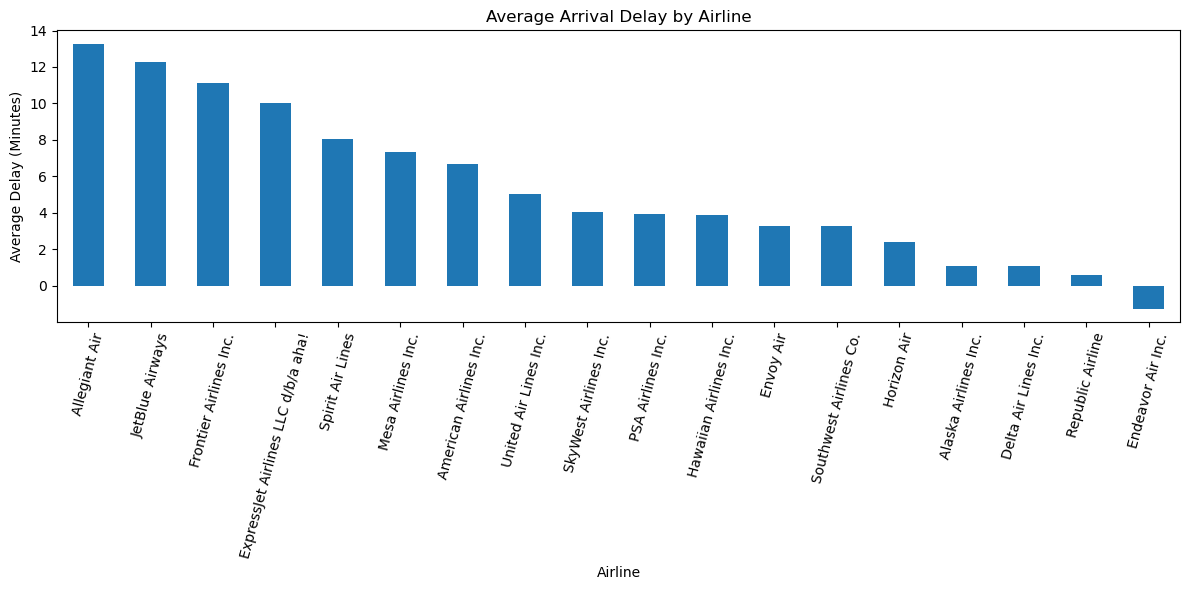

In [32]:
# Average arrival delay by airline
plt.figure(figsize=(12, 6))
airline_delay.plot(kind='bar')

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

## Delay Rate by Airline

While average delay (in minutes) provides useful insight, it may not fully reflect operational performance.

An airline may have a high average delay due to a few extreme cases, 
but that does not necessarily mean most of its flights are delayed.

Therefore, we now calculate the percentage of flights delayed 
(more than 15 minutes) for each airline.

This provides a clearer view of operational reliability.


In [35]:
# Calculate delay rate (%) by airline
airline_delay_rate = (df.groupby('AIRLINE')['IS_DELAYED'].mean()*100)

# Sort and round values
airline_delay_rate = airline_delay_rate.sort_values(ascending=False).round(2)

# Display formatted output with % sign
airline_delay_rate_formatted = airline_delay_rate.astype(str) + " %"

airline_delay_rate_formatted


AIRLINE
JetBlue Airways                        25.5 %
Frontier Airlines Inc.                25.22 %
Allegiant Air                         24.04 %
Spirit Air Lines                      20.87 %
ExpressJet Airlines LLC d/b/a aha!    19.58 %
American Airlines Inc.                18.65 %
United Air Lines Inc.                 18.08 %
Southwest Airlines Co.                17.89 %
Mesa Airlines Inc.                    17.36 %
Alaska Airlines Inc.                   17.0 %
Envoy Air                             16.19 %
PSA Airlines Inc.                     16.19 %
Hawaiian Airlines Inc.                15.28 %
SkyWest Airlines Inc.                 14.96 %
Republic Airline                      14.76 %
Delta Air Lines Inc.                  13.62 %
Horizon Air                           13.53 %
Endeavor Air Inc.                     12.32 %
Name: IS_DELAYED, dtype: object

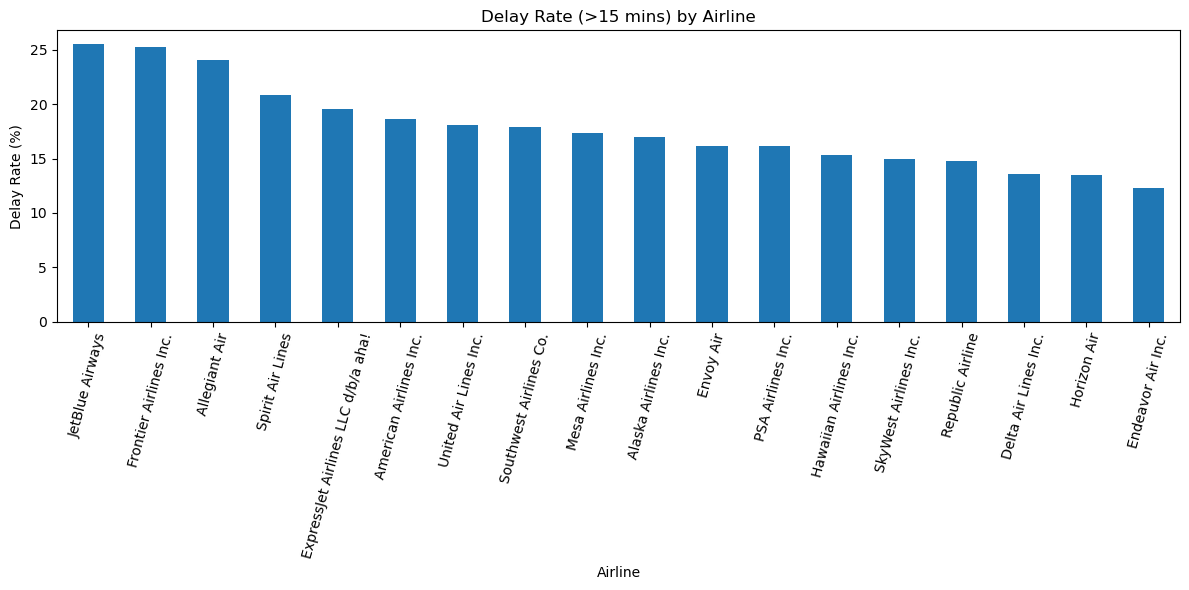

In [36]:
plt.figure(figsize=(12, 6))
airline_delay_rate.plot(kind='bar')

plt.title("Delay Rate (>15 mins) by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()


### Insight

The delay rate analysis reveals that JetBlue Airways, Frontier Airlines, and Allegiant Air experiences the highest proportion of delayed flights (approximately 24–25%).

This indicates that roughly one in four flights from these carriers is delayed by more than 15 minutes.

In contrast, airlines such as Delta Air Lines and Alaska Airlines show significantly lower delay rates (around 12–14%), reflecting stronger operational reliability.

These findings suggest that delay frequency varies substantially across carriers, highlighting differences in scheduling efficiency and operational performance.


## Monthly Delay Trend Analysis

Flight delays often vary by season due to factors such as weather conditions, peak travel demand, and air traffic congestion.

In this section, we:
- Convert the `FL_DATE` column into a proper datetime format
- Extract the month from each flight date
- Calculate the monthly delay rate (percentage of flights delayed by more than 15 minutes)
- Visualize the trend to identify seasonal patterns


In [39]:
# Convert FL_DATE to datetime (DD-MM-YYYY format)
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Check conversion
df['FL_DATE'].head()


0   2019-01-09
1   2022-11-19
2   2022-07-22
3   2023-03-06
4   2020-02-23
Name: FL_DATE, dtype: datetime64[ns]

In [42]:
# Extract month
df['MONTH'] = df['FL_DATE'].dt.month

# Calculate monthly delay rate (%)
monthly_delay_rate = (df.groupby('MONTH')['IS_DELAYED'].mean()*100)

# Sort correctly and round
monthly_delay_rate = monthly_delay_rate.sort_index().round(2)

# Adding % sign for display
monthly_delay_rate_formatted = monthly_delay_rate.astype(str) + " %"

monthly_delay_rate_formatted


MONTH
1     15.97 %
2     17.28 %
3     15.53 %
4     16.05 %
5     16.43 %
6     22.02 %
7     21.29 %
8     18.83 %
9     12.65 %
10    14.65 %
11    13.85 %
12    19.65 %
Name: IS_DELAYED, dtype: object

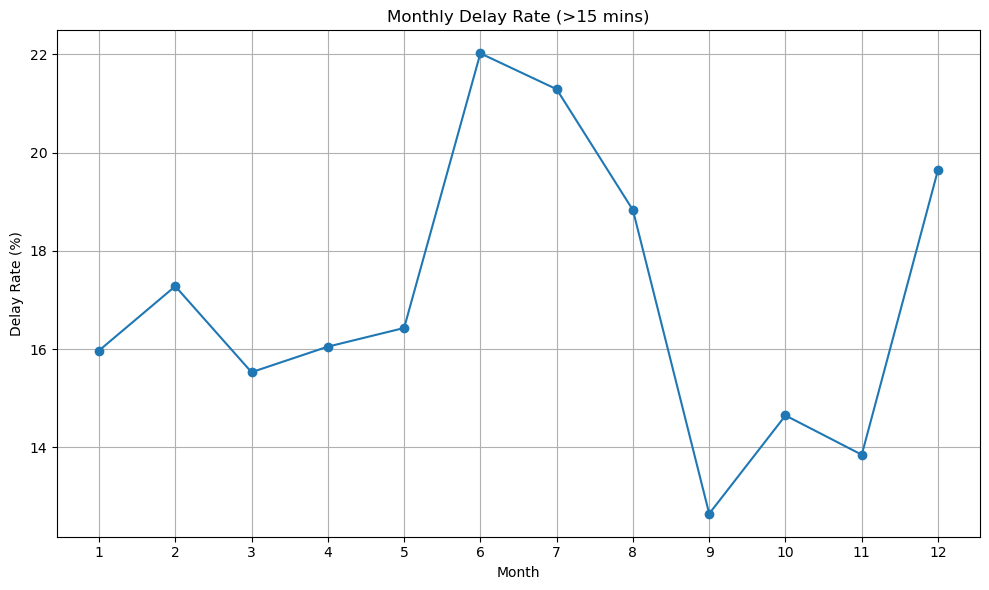

In [45]:
plt.figure(figsize=(10,6))
monthly_delay_rate.plot(marker='o')

plt.title("Monthly Delay Rate (>15 mins)")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()

plt.show()


### Insight

The monthly delay trend clearly demonstrates seasonality in flight performance.

Delay rates peak during June and July, likely due to increased summer travel demand and air traffic congestion. 
December also exhibits elevated delay rates, potentially influenced by holiday travel and adverse winter weather conditions.

September records the lowest delay rate, suggesting reduced operational strain following peak travel seasons.

This indicates that flight delays are strongly correlated with seasonal demand and weather-related factors.


## Delay Reason Contribution Analysis

Understanding when delays occur is important, but identifying *why* they occur 
provides deeper operational insight.

Flight delays may be caused by:

- Carrier-related operational issues
- Weather disruptions
- National Airspace System (NAS) congestion
- Security-related delays
- Late aircraft ripple effects

In this section, we analyze the total delay minutes attributed to each cause 
to determine the dominant contributors to flight delays.


In [47]:
# Define delay cause columns
delay_columns = [
    'DELAY_DUE_LATE_AIRCRAFT',
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_NAS',
    'DELAY_DUE_WEATHER'
]

# Calculate total delay minutes by cause
delay_totals = df[delay_columns].sum()

# Sort from highest to lowest
delay_totals = delay_totals.sort_values(ascending=False)

delay_totals


DELAY_DUE_LATE_AIRCRAFT   13598175.00
DELAY_DUE_CARRIER         13217960.00
DELAY_DUE_NAS              7028161.00
DELAY_DUE_WEATHER          2127583.00
DELAY_DUE_SECURITY           77907.00
dtype: float64

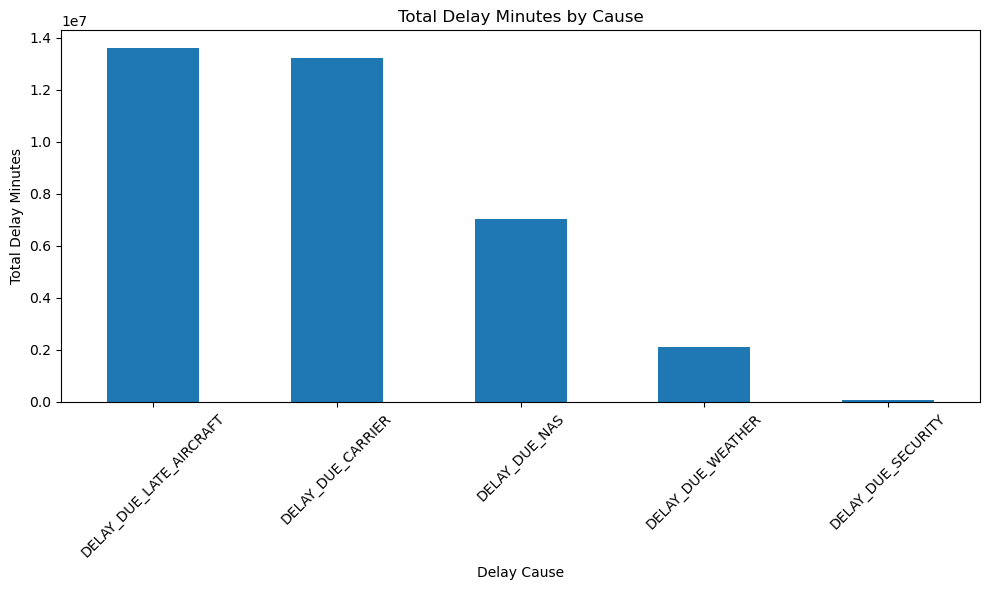

In [48]:
plt.figure(figsize=(10,6))
delay_totals.plot(kind='bar')

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


## Insight

The analysis of delay causes reveals that **Late Aircraft Delays** and **Carrier Delays** are the two largest contributors to total delay minutes.

Late aircraft delays indicate a ripple effect, where a delayed inbound flight causes subsequent departures to be delayed. This suggests operational scheduling and turnaround efficiency play a critical role in overall performance.

Carrier-related delays are also significant, highlighting internal operational factors such as crew availability, maintenance, and ground handling.

In contrast, Weather and Security delays contribute substantially less to total delay minutes, indicating that most delays are driven by operational inefficiencies rather than uncontrollable external factors.


# Final Summary & Business Insights

## Key Findings

1. **Delays are more frequent than cancellations**  
   The overall cancellation rate is relatively low (~2.64%), while approximately 17% of flights experience significant delays (>15 minutes).

2. **Operational delays dominate total delay minutes**  
   Late aircraft and carrier-related issues are the largest contributors to delays, indicating that operational inefficiencies have a greater impact than external factors such as weather or security.

3. **Airline performance varies significantly**  
   Some airlines consistently exhibit higher average delay minutes and higher delay rates, highlighting differences in operational efficiency.

4. **Clear seasonal patterns exist**  
   Delay rates peak during summer months (June–July) and increase again in December, suggesting demand congestion and weather-related seasonal effects.


## Business Implications

- Improving aircraft turnaround efficiency could significantly reduce total delay minutes.
- Optimizing scheduling buffers during peak summer months may improve on-time performance.
- Airlines with consistently high delay rates may require operational restructuring or resource allocation adjustments.
- Since operational factors outweigh weather impacts, internal process improvements could yield measurable gains.



## Conclusion

Flight delays are primarily driven by operational and scheduling inefficiencies rather than uncontrollable external events.

Improvements in aircraft turnaround management, crew scheduling, and planning capacity to peak times may enhance overall punctuality significantly.

This analysis demonstrates that data-driven operational insights can help airlines improve reliability and customer satisfaction.
